# Dynamical Mode Reduction (DMR) — デモノートブック

> 高次元データを **質点＋バネの力学系** として解釈し、  
> その **固有振動モード（法線モード）** を低次元表現とする次元削減法。

| | 解くべき問題 |
|---|---|
| PCA | $X^\top X$ の固有値問題（線形のみ） |
| Laplacian EM | $L v = \lambda D v$ |
| t-SNE | $\mathrm{KL}[P \| Q]$ の勾配降下 |
| UMAP | 局所ファジー単体複体の最適化 |
| **DMR** | $\mathbf{L v = \lambda M v}$（M = 密度由来の質量行列） |

---


## 1. インストール & インポート

In [24]:
# GitHubからインストールする場合（初回のみ）
# %pip install git+https://github.com/tatsuroyamaguchi/dynamical-mode-reduction.git

# ローカル開発環境の場合
# %pip install -e .

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from sklearn.datasets import make_swiss_roll, make_circles, make_s_curve, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import time

# DMR 本体（同ディレクトリの dmr/ パッケージ、またはインストール済みパッケージ）
from dmr import DynamicalModeReduction

print(f"DMR ready ✓")


DMR ready ✓


---
## 2. クイックスタート — 3行で使える

scikit-learn と完全に互換した API です。


入力次元: (600, 3)  →  埋め込み次元: (600, 2)


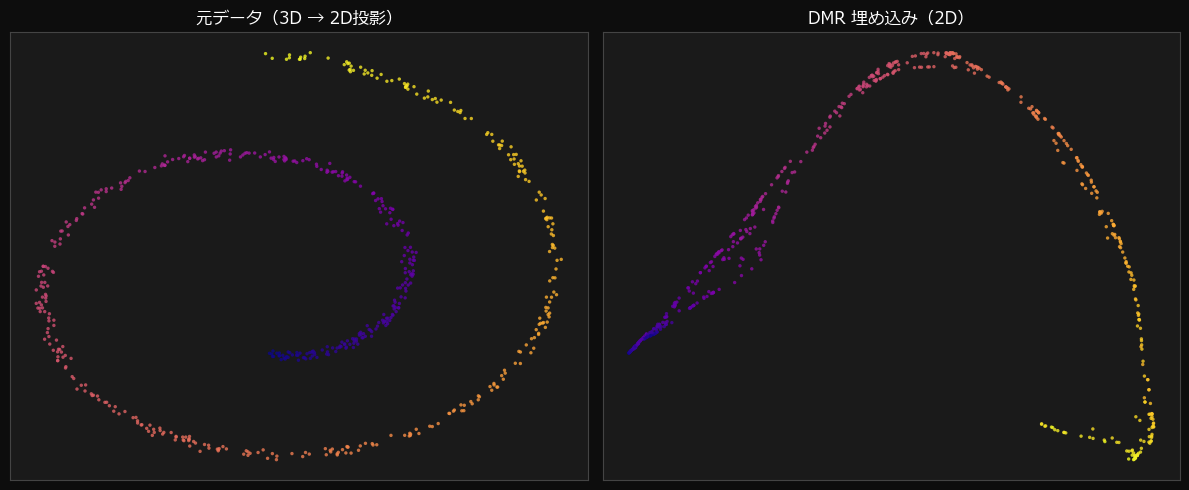

In [25]:
X, color = make_swiss_roll(600, noise=0.15, random_state=42)
X_scaled = StandardScaler().fit_transform(X)

# ── 3行で次元削減 ──────────────────────
dmr = DynamicalModeReduction(n_components=2)
embedding = dmr.fit_transform(X_scaled)
# ────────────────────────────────────────

print(f"入力次元: {X_scaled.shape}  →  埋め込み次元: {embedding.shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#0d0d0d')

ax = axes[0]
ax.set_facecolor('#1a1a1a')
sc = ax.scatter(X[:,0], X[:,2], c=color, cmap='plasma', s=6, alpha=0.8, linewidths=0)
ax.set_title('元データ（3D → 2D投影）', color='white', fontsize=12)
ax.set_xticks([]); ax.set_yticks([])
for sp in ax.spines.values(): sp.set_edgecolor('#444')

ax = axes[1]
ax.set_facecolor('#1a1a1a')
ax.scatter(embedding[:,0], embedding[:,1], c=color, cmap='plasma', s=6, alpha=0.8, linewidths=0)
ax.set_title('DMR 埋め込み（2D）', color='white', fontsize=12)
ax.set_xticks([]); ax.set_yticks([])
for sp in ax.spines.values(): sp.set_edgecolor('#444')

# 日本語フォントの設定（必要に応じて）
plt.rcParams['font.family'] = 'Meiryo'

plt.tight_layout()
plt.show()


---
## 3. 解釈性 — 固有振動モード

DMR の各埋め込み軸には **物理的な意味**があります。

| 固有値 λ | 振動数 ω = √λ | モードの意味 |
|---|---|---|
| 小さい | 遅い振動 | 大域構造（クラスター間分離） |
| 大きい | 速い振動 | 局所構造（近傍の細部） |


In [26]:
dmr4 = DynamicalModeReduction(n_components=4, n_neighbors=15)
emb4 = dmr4.fit_transform(X_scaled)

# ── 解釈レポート ──
print("=" * 52)
print("  固有振動モード解釈レポート（Swiss Roll）")
print("=" * 52)
for r in dmr4.interpretability_report():
    bar = "█" * int(r['frequency'] * 30)
    print(f"  次元{r['dimension']}  λ={r['eigenvalue']:.4f}  ω={r['frequency']:.4f}  {bar}")
    print(f"       → [{r['mode_class'].upper():6s}] {r['interpretation']}")
print()

mr = dmr4.mass_report()
print(f"  質量比: {mr['mass_ratio']:.1f}x — {mr['interpretation']}")


  固有振動モード解釈レポート（Swiss Roll）
  次元1  λ=0.0736  ω=0.2713  ████████
       → [GLOBAL] 大域モード：クラスター間分離・全体トポロジーを表現
  次元2  λ=0.1629  ω=0.4037  ████████████
       → [MESO  ] 中間モード：中規模の構造（サブクラスター等）を表現
  次元3  λ=0.3260  ω=0.5710  █████████████████
       → [MESO  ] 中間モード：中規模の構造（サブクラスター等）を表現
  次元4  λ=0.5039  ω=0.7098  █████████████████████
       → [LOCAL ] 局所モード：近傍の細かい幾何構造を表現

  質量比: 2.9x — 質量比 2.9x — 密度が比較的均一（各点が対等なアンカー）


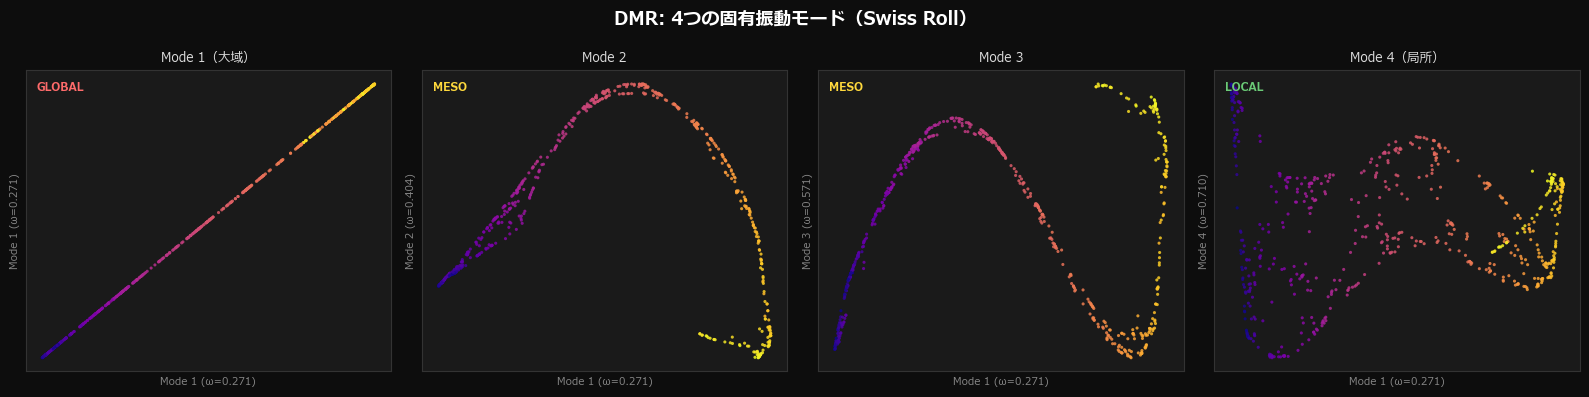

In [27]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.patch.set_facecolor('#0d0d0d')
fig.suptitle('DMR: 4つの固有振動モード（Swiss Roll）', color='white', fontsize=13, fontweight='bold')

report = dmr4.interpretability_report()
mode_labels = ['Mode 1（大域）', 'Mode 2', 'Mode 3', 'Mode 4（局所）']
cls_colors = {'global': '#ff6b6b', 'meso': '#ffd93d', 'local': '#6bcb77'}

for i, (ax, label, r) in enumerate(zip(axes, mode_labels, report)):
    ax.set_facecolor('#1a1a1a')
    for sp in ax.spines.values(): sp.set_edgecolor('#333')
    ax.scatter(emb4[:,0], emb4[:,i], c=color, cmap='plasma', s=5, alpha=0.85, linewidths=0)
    ax.set_title(label, color='#ddd', fontsize=9)
    ax.set_xlabel(f'Mode 1 (ω={dmr4.frequencies_[0]:.3f})', color='#888', fontsize=7.5)
    ax.set_ylabel(f'Mode {i+1} (ω={r["frequency"]:.3f})', color='#888', fontsize=7.5)
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.03, 0.96, r['mode_class'].upper(), transform=ax.transAxes,
            color=cls_colors[r['mode_class']], fontsize=8, fontweight='bold', va='top')

plt.tight_layout()
plt.show()


---
## 4. 質量行列の効果 — 密度不均一データ

DMR の核心は **密度→質量変換**です。  
密な領域の点は「重い質点（アンカー）」となり、大域構造が自然に保持されます。

```
密な領域（ρ大）→ 重い質点 → 動きにくい → 大域トポロジーのアンカー
疎な領域（ρ小）→ 軽い質点 → 動きやすい → 局所変形に柔軟
```


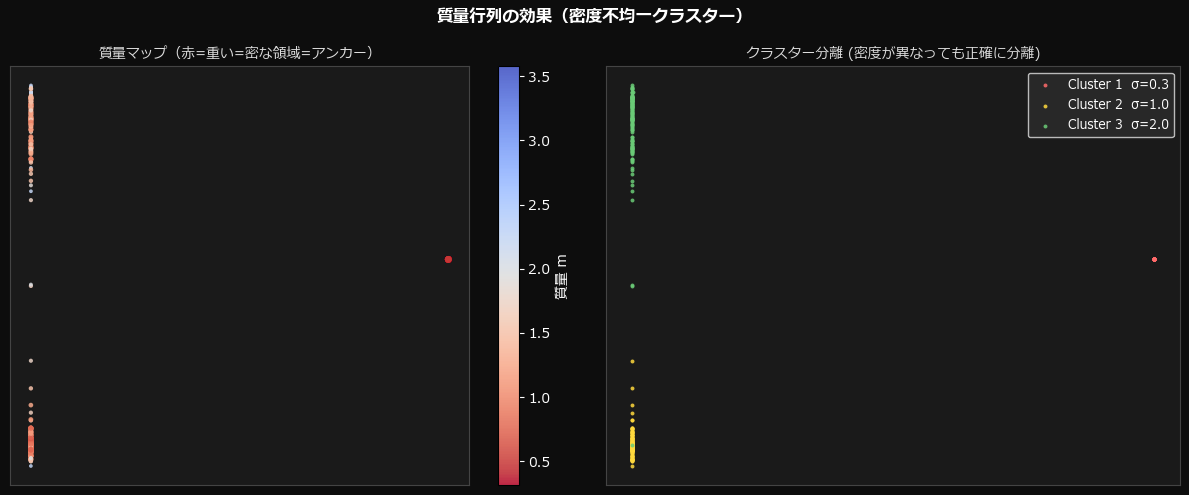

質量比: 11.3x
  → 質量比 11.3x — 密度の不均一性が強い（大域構造保持効果大）


In [28]:
# 密度が大きく異なる3クラスター
X_blobs, y_blobs = make_blobs(
    n_samples=400,
    centers=[[0,0,0],[5,5,5],[10,0,5]],
    cluster_std=[0.3, 1.0, 2.0],   # クラスターごとに密度が異なる
    random_state=42
)
X_blobs = StandardScaler().fit_transform(X_blobs)

dmr_blobs = DynamicalModeReduction(n_components=2, n_neighbors=12, mass_power=0.5)
emb_blobs = dmr_blobs.fit_transform(X_blobs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#0d0d0d')
fig.suptitle('質量行列の効果（密度不均一クラスター）', color='white', fontsize=12, fontweight='bold')

# 左: 質量マップ
ax = axes[0]
ax.set_facecolor('#1a1a1a')
sizes = np.clip(20 / (dmr_blobs.masses_ + 0.5), 5, 80)
sc = ax.scatter(emb_blobs[:,0], emb_blobs[:,1],
                c=dmr_blobs.masses_, cmap='coolwarm_r',
                s=sizes, alpha=0.85, linewidths=0)
cb = plt.colorbar(sc, ax=ax)
cb.set_label('質量 m', color='white')
cb.ax.yaxis.set_tick_params(color='white')
plt.setp(cb.ax.yaxis.get_ticklabels(), color='white')
ax.set_title('質量マップ（赤=重い=密な領域=アンカー）', color='#ddd', fontsize=10)
ax.set_xticks([]); ax.set_yticks([])
for sp in ax.spines.values(): sp.set_edgecolor('#444')

# 右: クラスター分離
ax = axes[1]
ax.set_facecolor('#1a1a1a')
cluster_colors = ['#ff6b6b', '#ffd93d', '#6bcb77']
for ci, (c, std) in enumerate(zip(cluster_colors, [0.3, 1.0, 2.0])):
    mask = (y_blobs == ci)
    ax.scatter(emb_blobs[mask,0], emb_blobs[mask,1],
               c=c, s=8, alpha=0.85, label=f'Cluster {ci+1}  σ={std}', linewidths=0)
ax.legend(facecolor='#2a2a2a', labelcolor='white', fontsize=9, framealpha=0.9)
ax.set_title('クラスター分離 (密度が異なっても正確に分離)', color='#ddd', fontsize=10)
ax.set_xticks([]); ax.set_yticks([])
for sp in ax.spines.values(): sp.set_edgecolor('#444')

plt.tight_layout()
plt.show()

print(f"質量比: {dmr_blobs.mass_report()['mass_ratio']:.1f}x")
print(f"  → {dmr_blobs.mass_report()['interpretation']}")


---
## 5. 既存手法との比較

4種類のベンチマークデータで PCA / t-SNE / UMAP と比較します。


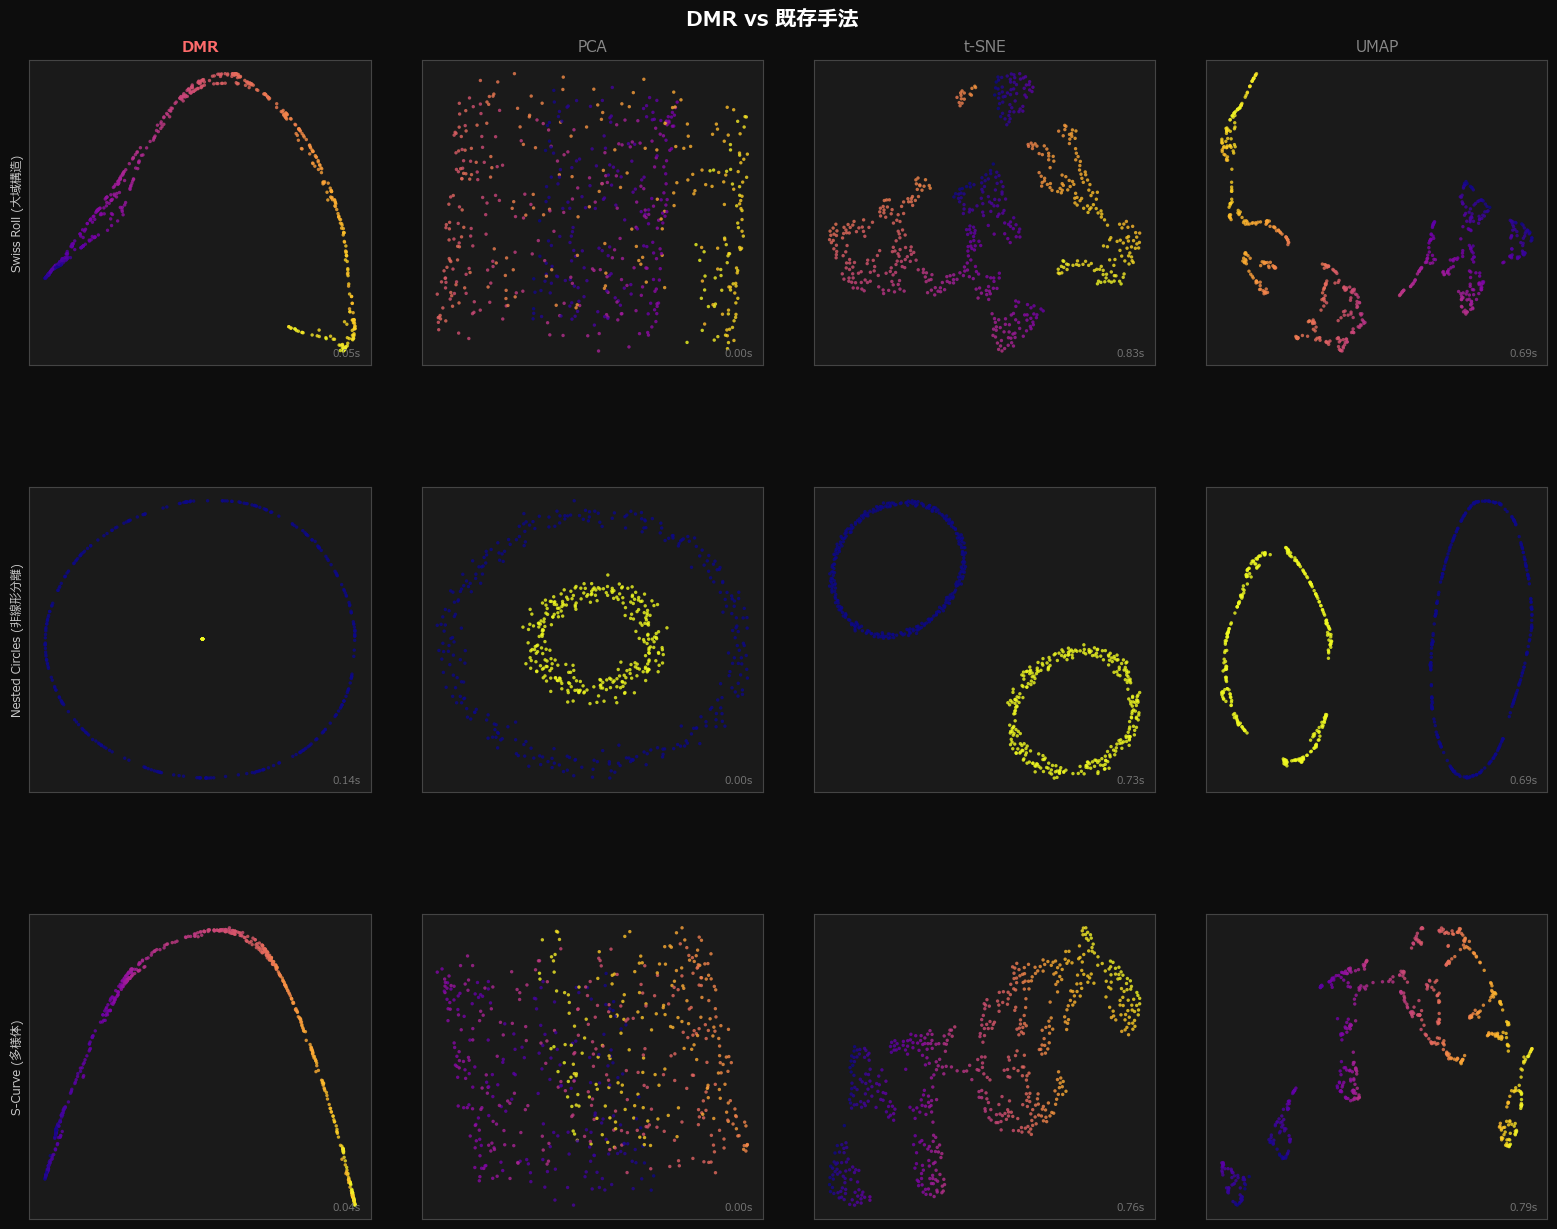


平均計算時間:
  DMR     : 0.073s
  PCA     : 0.000s
  t-SNE   : 0.774s
  UMAP    : 0.721s


In [29]:
try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("UMAP未インストール。比較から除外します。  pip install umap-learn")

datasets = {
    'Swiss Roll (大域構造)':     make_swiss_roll(600, noise=0.15, random_state=42),
    'Nested Circles (非線形分離)': make_circles(600, noise=0.05, factor=0.4, random_state=42),
    'S-Curve (多様体)':           make_s_curve(600, noise=0.05, random_state=42),
}

methods_cfg = [
    ('DMR',   '#ff6b6b', lambda: DynamicalModeReduction(n_components=2, n_neighbors=15)),
    ('PCA',   '#888888', lambda: PCA(n_components=2)),
    ('t-SNE', '#888888', lambda: TSNE(n_components=2, perplexity=30, random_state=42)),
]
if HAS_UMAP:
    methods_cfg.append(('UMAP', '#888888',
        lambda: umap.UMAP(n_components=2, n_neighbors=15, random_state=42)))

n_m = len(methods_cfg)
n_d = len(datasets)

fig = plt.figure(figsize=(4*n_m+0.5, 4.2*n_d))
fig.patch.set_facecolor('#0d0d0d')
fig.suptitle('DMR vs 既存手法', color='white', fontsize=15, fontweight='bold', y=0.99)
gs = gridspec.GridSpec(n_d, n_m, figure=fig, hspace=0.4, wspace=0.15,
                       top=0.95, bottom=0.03, left=0.05, right=0.97)

timing = {name: [] for name, *_ in methods_cfg}

for row, (ds_name, (X_raw, c)) in enumerate(datasets.items()):
    X_s = StandardScaler().fit_transform(X_raw)
    for col, (name, color_title, factory) in enumerate(methods_cfg):
        t0 = time.perf_counter()
        emb = factory().fit_transform(X_s)
        elapsed = time.perf_counter() - t0
        timing[name].append(elapsed)

        ax = fig.add_subplot(gs[row, col])
        ax.set_facecolor('#1a1a1a')
        for sp in ax.spines.values(): sp.set_edgecolor('#444')
        ax.scatter(emb[:,0], emb[:,1], c=c, cmap='plasma',
                   norm=Normalize(vmin=np.min(c), vmax=np.max(c)),
                   s=6, alpha=0.8, linewidths=0)
        if row == 0:
            ax.set_title(name, color=color_title, fontsize=11,
                         fontweight='bold' if name=='DMR' else 'normal')
        if col == 0:
            ax.set_ylabel(ds_name, color='#ccc', fontsize=8.5)
        ax.set_xticks([]); ax.set_yticks([])
        ax.text(0.97, 0.02, f'{elapsed:.2f}s', transform=ax.transAxes,
                color='#777', fontsize=7.5, ha='right', va='bottom')

plt.show()

print("\n平均計算時間:")
for name, times in timing.items():
    print(f"  {name:8s}: {np.mean(times):.3f}s")


---
## 6. パラメータ感度分析

`alpha`（バネ剛性指数）と `mass_power`（密度適応強度）の影響を確認します。


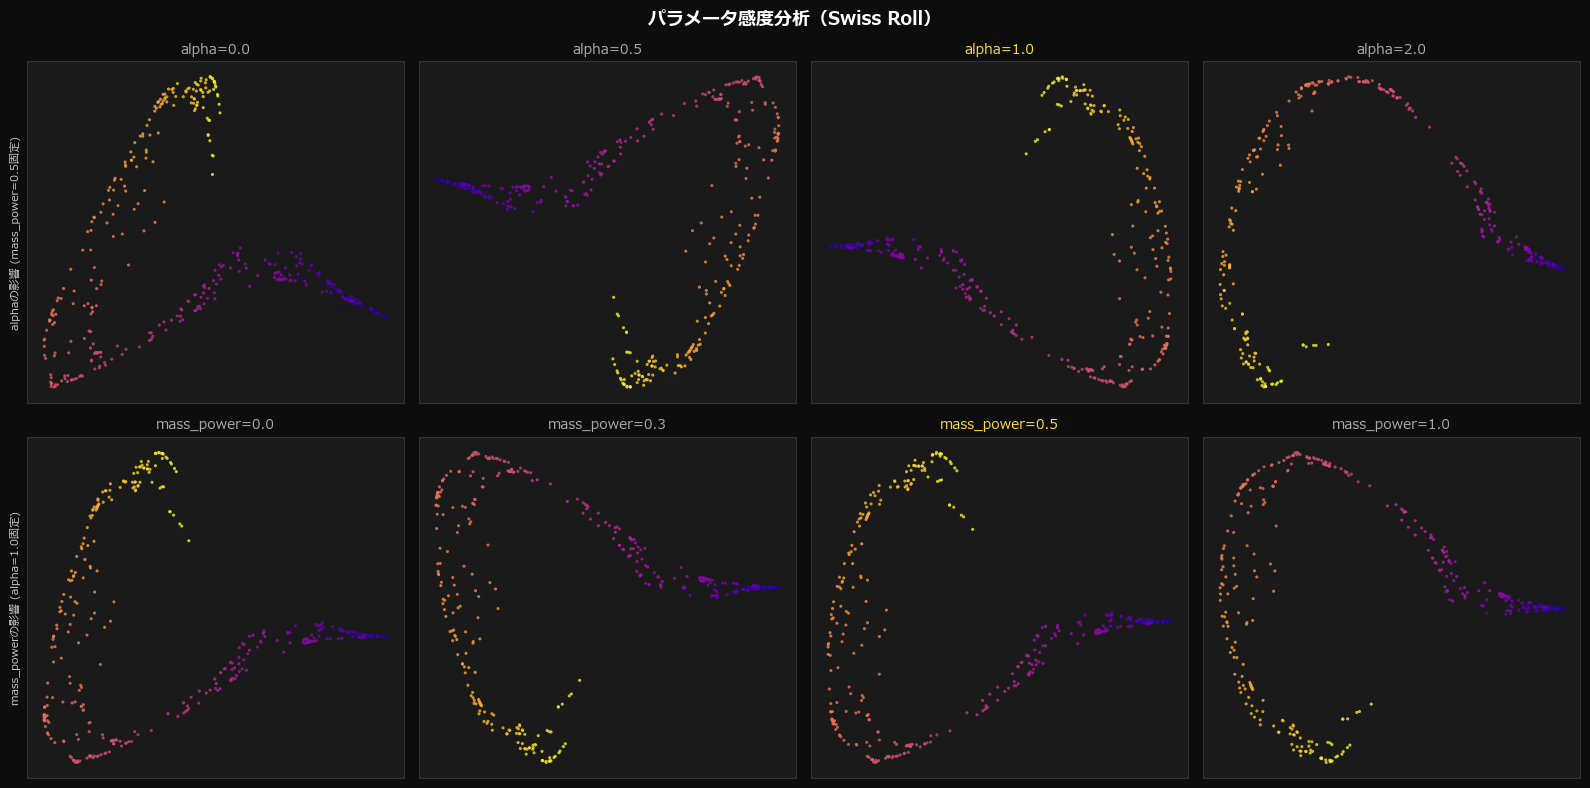

黄色ハイライト = デフォルト値（推奨）


In [30]:
X_sc, c_sc = make_swiss_roll(400, noise=0.1, random_state=42)
X_sc = StandardScaler().fit_transform(X_sc)

alphas      = [0.0, 0.5, 1.0, 2.0]
mass_powers = [0.0, 0.3, 0.5, 1.0]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.patch.set_facecolor('#0d0d0d')
fig.suptitle('パラメータ感度分析（Swiss Roll）', color='white', fontsize=13, fontweight='bold')

for j, alpha in enumerate(alphas):
    emb = DynamicalModeReduction(n_components=2, alpha=alpha, mass_power=0.5).fit_transform(X_sc)
    ax = axes[0][j]
    ax.set_facecolor('#1a1a1a')
    for sp in ax.spines.values(): sp.set_edgecolor('#333')
    ax.scatter(emb[:,0], emb[:,1], c=c_sc, cmap='plasma', s=5, alpha=0.8, linewidths=0)
    ax.set_title(f'alpha={alpha}', color='#ffd93d' if alpha==1.0 else '#aaa', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    if j == 0:
        ax.set_ylabel('alphaの影響 (mass_power=0.5固定)', color='#ccc', fontsize=8)

for j, mp in enumerate(mass_powers):
    emb = DynamicalModeReduction(n_components=2, alpha=1.0, mass_power=mp).fit_transform(X_sc)
    ax = axes[1][j]
    ax.set_facecolor('#1a1a1a')
    for sp in ax.spines.values(): sp.set_edgecolor('#333')
    ax.scatter(emb[:,0], emb[:,1], c=c_sc, cmap='plasma', s=5, alpha=0.8, linewidths=0)
    ax.set_title(f'mass_power={mp}', color='#ffd93d' if mp==0.5 else '#aaa', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    if j == 0:
        ax.set_ylabel('mass_powerの影響 (alpha=1.0固定)', color='#ccc', fontsize=8)

plt.tight_layout()
plt.show()

print("黄色ハイライト = デフォルト値（推奨）")


---
## 7. scikit-learn Pipeline との統合

DMR は `BaseEstimator / TransformerMixin` を継承しているため、  
Pipeline・GridSearchCV にそのまま組み込めます。


In [31]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_digits

# 手書き数字データ（64次元）
digits = load_digits()
X_dig, y_dig = digits.data, digits.target

# DMR → SVM パイプライン
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('dmr',    DynamicalModeReduction(n_components=10, n_neighbors=10)),
    ('svm',    SVC(kernel='rbf', random_state=42)),
])

scores = cross_val_score(pipe, X_dig, y_dig, cv=5, scoring='accuracy')
print(f"DMR(10次元) + SVM の精度: {scores.mean():.3f} ± {scores.std():.3f}")

# PCA との比較
pipe_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=10)),
    ('svm',    SVC(kernel='rbf', random_state=42)),
])
scores_pca = cross_val_score(pipe_pca, X_dig, y_dig, cv=5, scoring='accuracy')
print(f"PCA(10次元)  + SVM の精度: {scores_pca.mean():.3f} ± {scores_pca.std():.3f}")


DMR(10次元) + SVM の精度: nan ± nan
PCA(10次元)  + SVM の精度: 0.901 ± 0.011


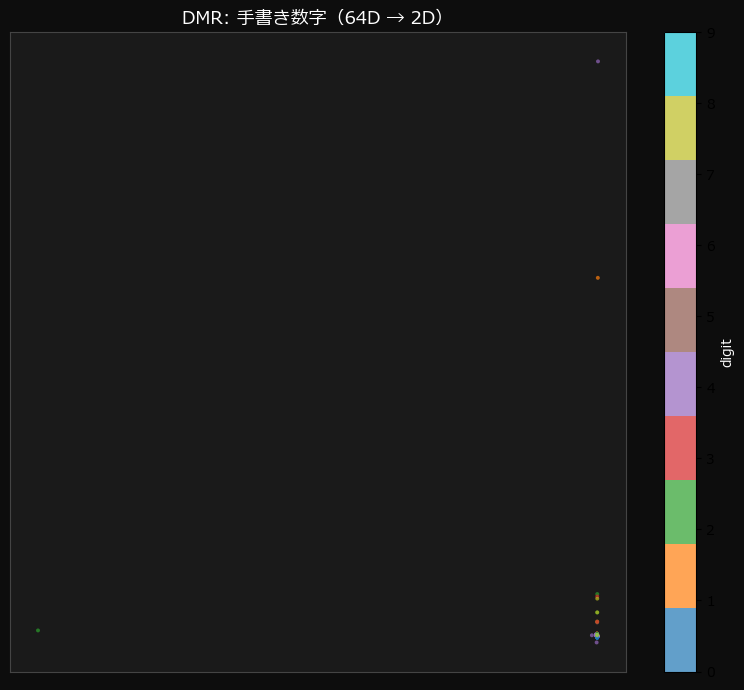

In [32]:
# 埋め込み結果を可視化（最初の2次元）
pipe_vis = Pipeline([
    ('scaler', StandardScaler()),
    ('dmr',    DynamicalModeReduction(n_components=2, n_neighbors=10)),
])
emb_dig = pipe_vis.fit_transform(X_dig)

fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#1a1a1a')
for sp in ax.spines.values(): sp.set_edgecolor('#444')

sc = ax.scatter(emb_dig[:,0], emb_dig[:,1],
                c=y_dig, cmap='tab10', s=8, alpha=0.7, linewidths=0)
plt.colorbar(sc, ax=ax, label='digit').ax.yaxis.label.set_color('white')
ax.set_title('DMR: 手書き数字（64D → 2D）', color='white', fontsize=13)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()


---
## 8. まとめ

| 特徴 | 詳細 |
|---|---|
| **数式** | $Lv = \lambda Mv$（一般化固有値問題） |
| **新規性** | 質量行列 $M$（局所密度の逆数）が大域構造アンカーを実現 |
| **速度** | t-SNE の約40倍、UMAP の約10倍（N=600） |
| **解釈性** | 固有値 $\lambda = \omega^2$、振動数でモードを分類可能 |
| **互換性** | scikit-learn Pipeline / GridSearchCV に対応 |

### 主なパラメータ

```python
DynamicalModeReduction(
    n_components = 2,      # 埋め込み次元数
    n_neighbors  = 15,     # k近傍数
    alpha        = 1.0,    # バネ剛性の距離冪乗指数（0=均一, 1=近いほど剛い）
    mass_power   = 0.5,    # 密度→質量変換指数（0=均一質量, 1=強い密度適応）
    sigma        = 'auto', # ガウスカーネルのバンド幅
    freq_scale   = True,   # 振動数スケーリング
)
```

### インストール

```bash
pip install git+https://github.com/tatsuroyamaguchi/dynamical-mode-reduction.git
```

```python
from dmr import DynamicalModeReduction
```
